In [18]:
import os
# disable oneDNN optimizations and silences most TF log messages
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL']   = '2'

import random
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

# Import sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Import keras helpers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import CategoricalCrossentropy

In [6]:
# set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# define directory layout
DATA_RAW_DIR       = "data/raw"
DATA_PROCESSED_DIR = "data/processed"
FIGURES_DIR        = "outputs/figures"
MODELS_DIR         = "outputs/models"
RESULTS_DIR        = "results"

In [4]:
# create directories if they don't exist
for d in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [5]:
# download raw mnist archive and copy to data/raw
data_url        = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
cached_path     = tf.keras.utils.get_file("mnist.npz", data_url)  # downloads to ~/.keras/datasets
raw_data_path   = os.path.join(DATA_RAW_DIR, "mnist.npz")
if not os.path.exists(raw_data_path):
    shutil.copy(cached_path, raw_data_path)

In [6]:
# load arrays from the raw archive
with np.load(raw_data_path) as data:
    x_train_orig = data["x_train"]   # (60000, 28, 28)
    y_train_orig = data["y_train"]   # (60000,)
    x_test_orig  = data["x_test"]    # (10000, 28, 28)
    y_test_orig  = data["y_test"]    # (10000,)

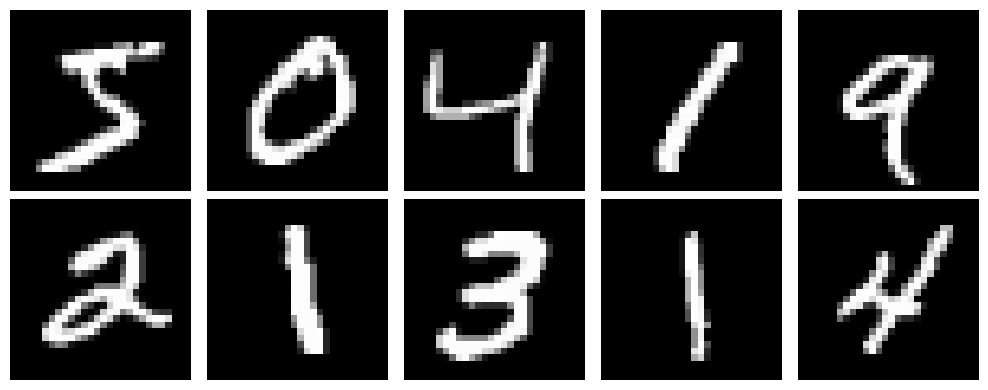

In [7]:
# display and save a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train_orig[i], cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "sample_images.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [8]:
# split train/val and save processed datasets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_orig, 
    y_train_orig, 
    test_size=0.10, 
    random_state=42, 
    shuffle=True
)
x_test, y_test = x_test_orig, y_test_orig

# save splits as compressed npz for reproducibility
np.savez_compressed(
    os.path.join(DATA_PROCESSED_DIR, "train.npz"),
    x=x_train, y=y_train
)
np.savez_compressed(
    os.path.join(DATA_PROCESSED_DIR, "val.npz"),
    x=x_val, y=y_val
)
np.savez_compressed(
    os.path.join(DATA_PROCESSED_DIR, "test.npz"),
    x=x_test, y=y_test
)

# sanity‑check
print(f"train: {x_train.shape, y_train.shape}")
print(f"val:   {x_val.shape,   y_val.shape}")
print(f"test:  {x_test.shape,  y_test.shape}")

train: ((54000, 28, 28), (54000,))
val:   ((6000, 28, 28), (6000,))
test:  ((10000, 28, 28), (10000,))


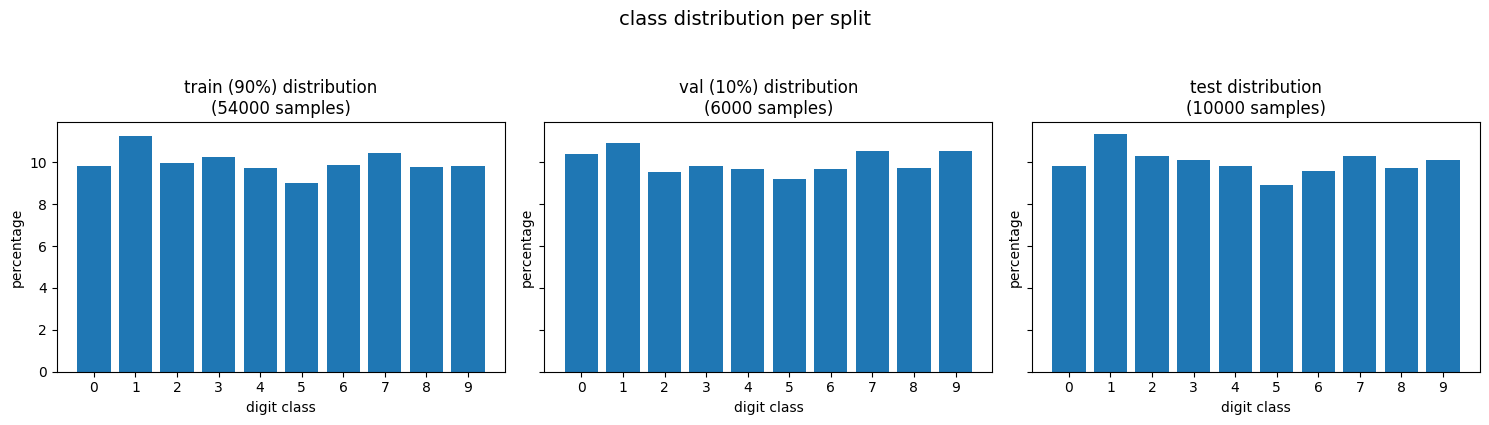

In [9]:
# visualize and save class distributions for train, val, and test
classes     = [str(i) for i in range(10)]
num_classes = len(classes)

train_labels = y_train
val_labels   = y_val
test_labels  = y_test

# count occurrences per class
train_counts = np.bincount(train_labels, minlength=num_classes)
val_counts   = np.bincount(val_labels,   minlength=num_classes)
test_counts  = np.bincount(test_labels,  minlength=num_classes)

# convert to percentages per split
train_pct = train_counts / train_counts.sum() * 100
val_pct   = val_counts   / val_counts.sum()   * 100
test_pct  = test_counts  / test_counts.sum()  * 100

# split sizes and their overall ratios
split_info = [
    ("train (90%)", train_counts.sum()),
    ("val (10%)",   val_counts.sum()),
    ("test",        test_counts.sum())
]

# plot side‑by‑side bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, pct, (title, count) in zip(
    axes,
    [train_pct, val_pct, test_pct],
    split_info
):
    ax.bar(range(num_classes), pct)
    ax.set_title(f"{title} distribution\n({count} samples)")
    ax.set_xlabel("digit class")
    ax.set_ylabel("percentage")
    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(classes)

# add overall subtitle
fig.suptitle("class distribution per split", fontsize=14, y=1.05)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "class_distribution.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [13]:
# data generator parameters
IMAGE_WIDTH   = 28
IMAGE_HEIGHT  = 28
IMAGE_DEPTH   = 1
BATCH_SIZE    = 64
NUM_CLASSES   = 10

# load processed splits
train_npz = np.load(os.path.join(DATA_PROCESSED_DIR, "train.npz"))
val_npz   = np.load(os.path.join(DATA_PROCESSED_DIR, "val.npz"))
test_npz  = np.load(os.path.join(DATA_PROCESSED_DIR, "test.npz"))

x_train, y_train = train_npz["x"], train_npz["y"]
x_val,   y_val   = val_npz["x"],   val_npz["y"]
x_test,  y_test  = test_npz["x"],  test_npz["y"]

# one‑hot encode labels
y_train = to_categorical(y_train, NUM_CLASSES)
y_val   = to_categorical(y_val,   NUM_CLASSES)
y_test  = to_categorical(y_test,  NUM_CLASSES)

# create image data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# build generators
train_generator = train_datagen.flow(
    x_train.reshape(-1, IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_DEPTH),
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)
validation_generator = val_datagen.flow(
    x_val.reshape(-1, IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_DEPTH),
    y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_generator = test_datagen.flow(
    x_test.reshape(-1, IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_DEPTH),
    y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [14]:
# model and head hyperparameters
PRE_TRAIN_WIDTH    = 224
PRE_TRAIN_HEIGHT   = 224
NUM_CLASSES        = 10
HEAD_UNITS_1       = 256
HEAD_UNITS_2       = 128
L2_WEIGHT_DECAY    = 1e-5
DROPOUT_RATE       = 0.3
INITIAL_LR         = 1e-3
LABEL_SMOOTHING    = 0.05
CLASS_NAMES        = [str(i) for i in range(NUM_CLASSES)]

def build_model():
    # load mobilenetv2 feature extractor
    base = tf.keras.applications.MobileNetV2(
        input_shape=(PRE_TRAIN_HEIGHT, PRE_TRAIN_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    # mnist input
    inp = tf.keras.Input((IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_DEPTH))
    # resize + rgb
    x = tf.keras.layers.Resizing(PRE_TRAIN_HEIGHT, PRE_TRAIN_WIDTH)(inp)
    x = tf.keras.layers.Concatenate()([x, x, x])
    # feature extraction
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # head block 1
    x = tf.keras.layers.Dense(
        HEAD_UNITS_1,
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)

    # head block 2
    x = tf.keras.layers.Dense(
        HEAD_UNITS_2,
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)

    # output layer
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    # compile
    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=INITIAL_LR),
        loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"]
    )
    return model, base

# build and summarize
model, base_model = build_model()
model.summary()

In [12]:
# pretraining parameters
EPOCHS = 30

def train_model():
    # early stop on val_accuracy stagnation
    es = EarlyStopping(
        monitor="val_accuracy",
        min_delta=8e-05,
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    # lr reduction on plateau
    rlrop = ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.25,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
    # train model
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS,
        steps_per_epoch=len(train_generator),
        validation_steps=len(validation_generator),
        callbacks=[es, rlrop],
        verbose=1
    )
    return history

# run pretraining
hist = train_model()

Epoch 1/30


/home/jupyter-noz224/.conda/envs/MNIST/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1744958953.082523 1685207 service.cc:152] XLA service 0x7f3868010fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744958953.082593 1685207 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1744958953.082610 1685207 service.cc:160]   StreamExecutor device (1): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1744958953.082623 1685207 service.cc:160]   StreamExecutor device (2): NVIDIA RTX A5000, Compute Capability 8.6
I0000 00:00:1744958953.082631 1685207 service.cc:160]   Str

  5/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.0926 - loss: 2.7576 

I0000 00:00:1744958964.745075 1685207 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 57ms/step - accuracy: 0.8436 - loss: 0.7497 - val_accuracy: 0.9532 - val_loss: 0.4500 - learning_rate: 0.0010
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9468 - loss: 0.4774 - val_accuracy: 0.9617 - val_loss: 0.4307 - learning_rate: 0.0010
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9529 - loss: 0.4552 - val_accuracy: 0.9653 - val_loss: 0.4125 - learning_rate: 0.0010
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.9558 - loss: 0.4439 - val_accuracy: 0.9567 - val_loss: 0.4352 - learning_rate: 0.0010
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9590 - loss: 0.4346 - val_accuracy: 0.9613 - val_loss: 0.4177 - learning_rate: 0.0010
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9606 - loss: 0.4299 - val_accuracy: 0.9683 - val_loss: 0.4003 - learning_rate: 0.0010
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9650 - loss: 0.4201

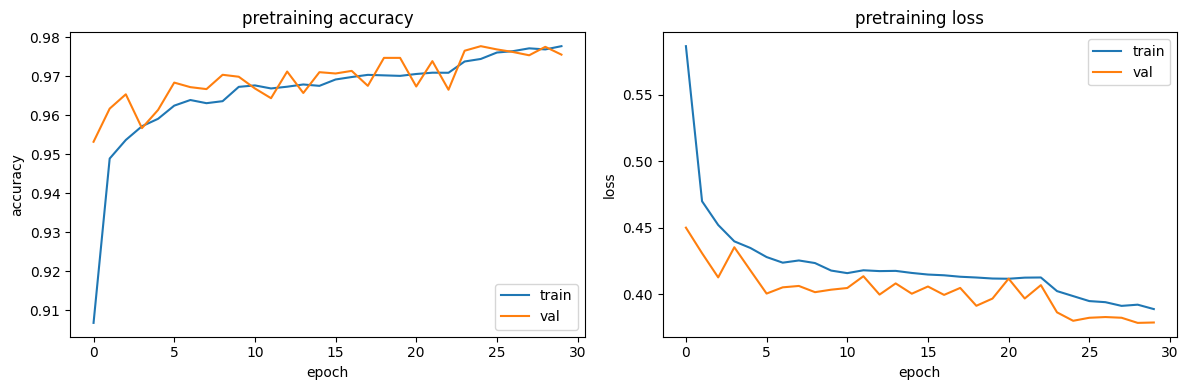

In [13]:
# visualize and save pretraining history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy
axes[0].plot(hist.history['accuracy'], label='train')
axes[0].plot(hist.history['val_accuracy'], label='val')
axes[0].set_title('pretraining accuracy')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend(loc='lower right')

# loss
axes[1].plot(hist.history['loss'], label='train')
axes[1].plot(hist.history['val_loss'], label='val')
axes[1].set_title('pretraining loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "pretraining_history.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

/home/jupyter-noz224/.conda/envs/MNIST/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step
accuracy         : 0.9738
f1 (macro)       : 0.9732
f1 (weighted)    : 0.9738
auc‑roc (macro)  : 0.9993
auc‑roc (micro)  : 0.9995

classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.95      0.95      1032
           3       0.95      0.96      0.96      1010
           4       0.97      0.99      0.98       982
           5       0.94      0.93      0.94       892
           6       0.99      0.97      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



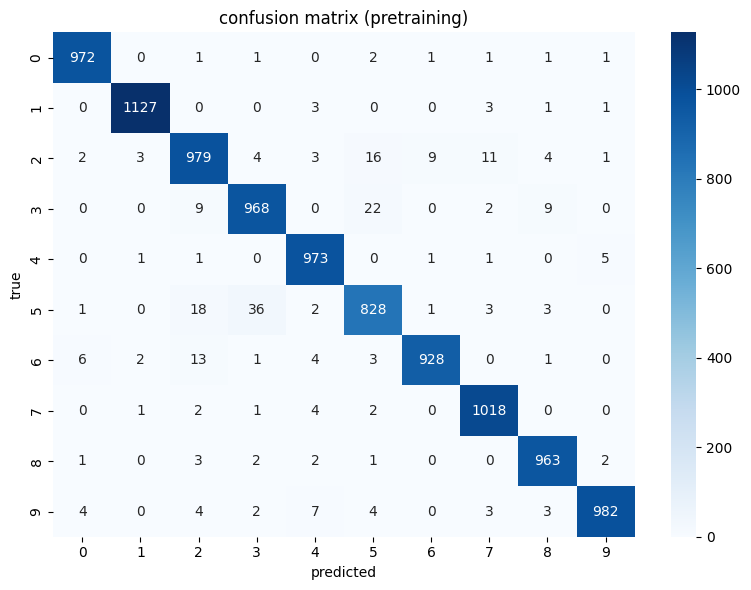

In [14]:
# evaluate pretrained model on test set
y_pred_prob = model.predict(test_generator)
y_true      = np.argmax(y_test, axis=1)
y_pred      = np.argmax(y_pred_prob, axis=1)

# compute basic metrics
acc          = accuracy_score(y_true, y_pred)
f1_macro     = f1_score(y_true, y_pred, average='macro')
f1_weighted  = f1_score(y_true, y_pred, average='weighted')

# compute multiclass auc‑roc
y_bin        = to_categorical(y_true, NUM_CLASSES)
auc_macro    = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='macro')
auc_micro    = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='micro')

# print summary
print(f"accuracy         : {acc:.4f}")
print(f"f1 (macro)       : {f1_macro:.4f}")
print(f"f1 (weighted)    : {f1_weighted:.4f}")
print(f"auc‑roc (macro)  : {auc_macro:.4f}")
print(f"auc‑roc (micro)  : {auc_micro:.4f}\n")

# detailed classification report
print("classification report:")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

# plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('confusion matrix (pretraining)')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "confusion_matrix_pretrain.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [16]:
# fine‑tuning parameters
FINE_TUNE_EPOCHS = 20

def fine_tune_model():
    # unfreeze last 20 layers of the base model
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    # recompile with low lr, weight decay, and label smoothing
    model.compile(
        optimizer=AdamW(learning_rate=5e-6, weight_decay=L2_WEIGHT_DECAY),
        loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"]
    )

    # early stop on val_accuracy
    es = EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    # reduce lr on plateau
    rlrop = ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )

    # continue training for fine‑tune epochs
    history_ft = model.fit(
        train_generator,
        validation_data=validation_generator,
        initial_epoch=hist.epoch[-1] + 1,
        epochs=hist.epoch[-1] + 1 + FINE_TUNE_EPOCHS,
        steps_per_epoch=len(train_generator),
        validation_steps=len(validation_generator),
        callbacks=[es, rlrop],
        verbose=1
    )
    return history_ft

# run fine‑tuning
hist_ft = fine_tune_model()

Epoch 31/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 48ms/step - accuracy: 0.9775 - loss: 0.3905 - val_accuracy: 0.9813 - val_loss: 0.3681 - learning_rate: 5.0000e-06
Epoch 32/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9775 - loss: 0.3884 - val_accuracy: 0.9820 - val_loss: 0.3656 - learning_rate: 5.0000e-06
Epoch 33/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9777 - loss: 0.3871 - val_accuracy: 0.9823 - val_loss: 0.3634 - learning_rate: 5.0000e-06
Epoch 34/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9783 - loss: 0.3849 - val_accuracy: 0.9832 - val_loss: 0.3626 - learning_rate: 5.0000e-06
Epoch 35/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9803 - loss: 0.3823 - val_accuracy: 0.9827 - val_loss: 0.3636 - learning_rate: 5.0000e-06
Epoch 36/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9805 - loss: 0.3818 - val_accuracy: 0.9843 - val_loss: 0.3603 - learning_rate: 5.0000e-06
Epoch 37/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 3

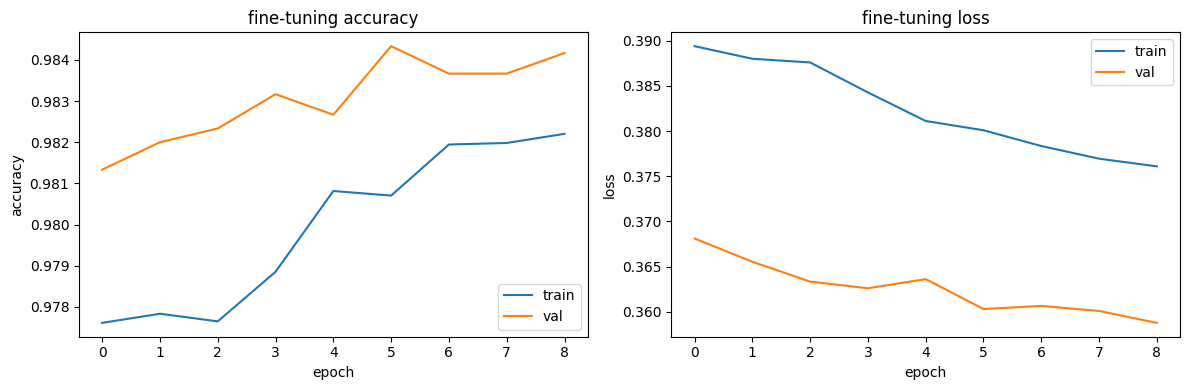

In [17]:
# visualize and save fine‑tuning history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy
axes[0].plot(hist_ft.history['accuracy'], label='train')
axes[0].plot(hist_ft.history['val_accuracy'], label='val')
axes[0].set_title('fine‑tuning accuracy')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend(loc='lower right')

# loss
axes[1].plot(hist_ft.history['loss'], label='train')
axes[1].plot(hist_ft.history['val_loss'], label='val')
axes[1].set_title('fine‑tuning loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "finetuning_history.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step
final accuracy        : 0.9824
final f1 (macro)      : 0.9821
final f1 (weighted)   : 0.9824
final auc‑roc (macro) : 0.9996
final auc‑roc (micro) : 0.9997

final classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.99      0.99       982
           5       0.97      0.96      0.97       892
           6       0.99      0.97      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



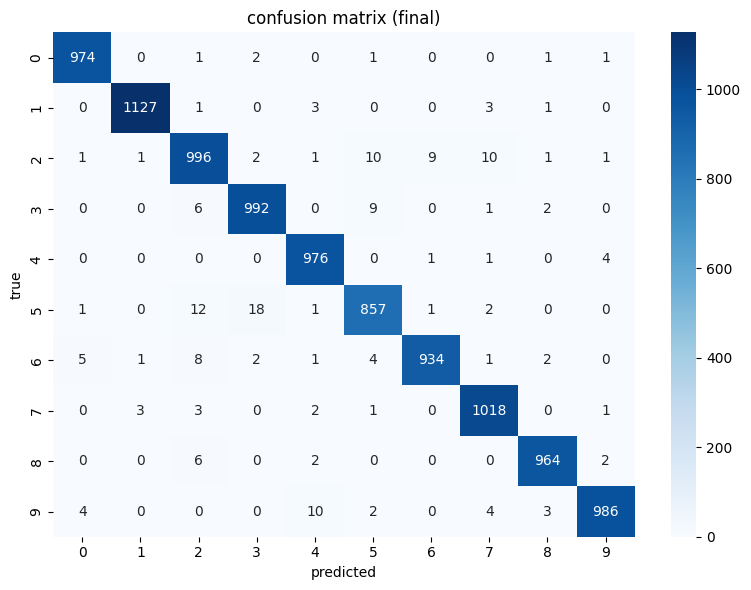

In [18]:
# final evaluation on test set after fine‑tuning
y_prob_final = model.predict(test_generator)
y_true       = np.argmax(y_test, axis=1)
y_pred_final = np.argmax(y_prob_final, axis=1)

# compute metrics
acc_final       = accuracy_score(y_true, y_pred_final)
f1_macro_final  = f1_score(y_true, y_pred_final, average='macro')
f1_weighted_final = f1_score(y_true, y_pred_final, average='weighted')
y_bin_final     = to_categorical(y_true, NUM_CLASSES)
auc_macro_final = roc_auc_score(y_bin_final, y_prob_final, multi_class='ovr', average='macro')
auc_micro_final = roc_auc_score(y_bin_final, y_prob_final, multi_class='ovr', average='micro')

# print summary
print(f"final accuracy        : {acc_final:.4f}")
print(f"final f1 (macro)      : {f1_macro_final:.4f}")
print(f"final f1 (weighted)   : {f1_weighted_final:.4f}")
print(f"final auc‑roc (macro) : {auc_macro_final:.4f}")
print(f"final auc‑roc (micro) : {auc_micro_final:.4f}\n")

# detailed classification report
print("final classification report:")
print(classification_report(
    y_true, y_pred_final,
    target_names=CLASS_NAMES,
    zero_division=0
))

# plot and save confusion matrix
cm_final = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('confusion matrix (final)')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "confusion_matrix_final.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [19]:
# save final fine‑tuned model
final_model_path = os.path.join(MODELS_DIR, "mobilenet_finetuned.keras")
model.save(final_model_path)
print(f"saved fine‑tuned model to {final_model_path}")

saved fine‑tuned model to outputs/models/mobilenet_finetuned.keras
